In [4]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载数据集
def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set')
    train_label = load('../dataresult/train_label')
    # 测试集
    test_set = load('../dataresult/test_set')
    test_label = load('../dataresult/test_label')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader

batch_size = 32
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

114
73


In [5]:
class CNNModel(nn.Module):
    def __init__(self, input_dim, conv_archs, output_dim):
        super().__init__()
        self.conv_arch = conv_archs
        self.input_channels = input_dim
        self.cnn_features = self.make_layers()
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 修改的全连接层
        conv_output_channels = conv_archs[-1][-1]
        self.linear = nn.Sequential(
            nn.Linear(conv_output_channels, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
        )

    def make_layers(self):
        layers = []
        for i, (num_convs, out_channels) in enumerate(self.conv_arch):
            for j in range(num_convs):
                layers.append(nn.Conv1d(self.input_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.BatchNorm1d(out_channels))  # 新增
                layers.append(nn.ReLU(inplace=True))

                if j == num_convs - 1 and i > 0:  # 只在第二个卷积块的最后一层
                    layers.append(nn.Dropout1d(0.1))  # 降低dropout率

                self.input_channels = out_channels

            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, input_seq):
        batch_size = input_seq.size(0)
        input_seq = input_seq.permute(0, 2, 1)
        cnn_features = self.cnn_features(input_seq)
        x = self.avgpool(cnn_features)
        flat_tensor = x.view(batch_size, -1)
        predict = self.linear(flat_tensor)
        return predict

In [6]:
# 定义模型参数
input_dim = 13   # 输入维度为14维数据
# CNN 网络结构 参考经典CNN网络模型 VGG 必看，不然看不懂相关参数设置
conv_archs = ((1, 32), (1, 64))  # 层数，和每层通道数
output_dim = 1 # 输出维度为 1

model = CNNModel(input_dim, conv_archs, output_dim)  

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0005
optimizer = torch.optim.Adam(model.parameters(),  # 改为Adam
                             lr=learn_rate,
                             weight_decay=0.0005)  # 添加L2正则化

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

  1248
    32
    32
    32
  6144
    64
    64
    64
  2048
    32
    32
     1
______
  9793


In [7]:
print(model)

CNNModel(
  (cnn_features): Sequential(
    (0): Conv1d(13, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout1d(p=0.1, inplace=False)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool1d(output_size=1)
  (linear): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(epochs, model, optimizer, loss_function, train_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
         # 训练
        model.train()
        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')
       
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数
         
    # 保存最后的参数
    # torch.save(model, 'final_model_cnn.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_cnn.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    # plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    # plt.legend()
    # plt.show()   #显示 lable
    # print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 50
model_train(epochs, model, optimizer, loss_function, train_loader, device)

Epoch:  1 train_MSE-Loss: 0.08702876
Epoch:  2 train_MSE-Loss: 0.07817506
Epoch:  3 train_MSE-Loss: 0.07459919
Epoch:  4 train_MSE-Loss: 0.06353576
Epoch:  5 train_MSE-Loss: 0.05284706
Epoch:  6 train_MSE-Loss: 0.04627202
Epoch:  7 train_MSE-Loss: 0.04367076
Epoch:  8 train_MSE-Loss: 0.03920579
Epoch:  9 train_MSE-Loss: 0.03727035
Epoch: 10 train_MSE-Loss: 0.03425019
Epoch: 11 train_MSE-Loss: 0.03131421
Epoch: 12 train_MSE-Loss: 0.02913900
Epoch: 13 train_MSE-Loss: 0.02767978
Epoch: 14 train_MSE-Loss: 0.02597723
Epoch: 15 train_MSE-Loss: 0.02602611
Epoch: 16 train_MSE-Loss: 0.02458912
Epoch: 17 train_MSE-Loss: 0.02402928
Epoch: 18 train_MSE-Loss: 0.02299887
Epoch: 19 train_MSE-Loss: 0.02228592
Epoch: 20 train_MSE-Loss: 0.02164870
Epoch: 21 train_MSE-Loss: 0.02097747
Epoch: 22 train_MSE-Loss: 0.02031924
Epoch: 23 train_MSE-Loss: 0.02087393
Epoch: 24 train_MSE-Loss: 0.01983529
Epoch: 25 train_MSE-Loss: 0.01927946
Epoch: 26 train_MSE-Loss: 0.01828573
Epoch: 27 train_MSE-Loss: 0.01787679
E

### 第一部分，训练集评估

In [9]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

/tmp/ipykernel_3004951/2190353117.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_cnn.pt')


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
# scaler  = load('../dataresult/scaler')
# origin_data = scaler.inverse_transform(origin_data)
# pre_data = scaler.inverse_transform(pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.1300889984343273
**************************************************
训练数据集上的均方误差-MSE:  0.0714788844542712
训练数据集上的均方根误差-RMSE:  0.267355352395031
训练数据集上的平均绝对误差-MAE:  0.23198935535214205


# 测试集评估

In [12]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test__pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test__pre_data += pred        

/tmp/ipykernel_3004951/606097058.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_cnn.pt')


In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
# scaler  = load('../dataresult/scaler')
# test_origin_data = scaler.inverse_transform(test_origin_data)
# test__pre_data = scaler.inverse_transform(test__pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test__pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test__pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test__pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: -0.27152243917640106
**************************************************
测试数据集上的均方误差-MSE:  0.10250880077970873
测试数据集上的均方根误差-RMSE:  0.3201699560853715
测试数据集上的平均绝对误差-MAE:  0.2820217474048785


findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
/home/2025-Zhang.qf/miniconda3/envs/test_py/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23551 (\N{CJK UNIFIED IDEOGRAPH-5BFF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/2025-Zhang.qf/miniconda3/envs/test_py/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21629 (\N{CJK UNIFIED IDEOGRAPH-547D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/2025-Zhang.qf/miniconda3/envs/test_py/lib/python3.8/site-packages/IPython

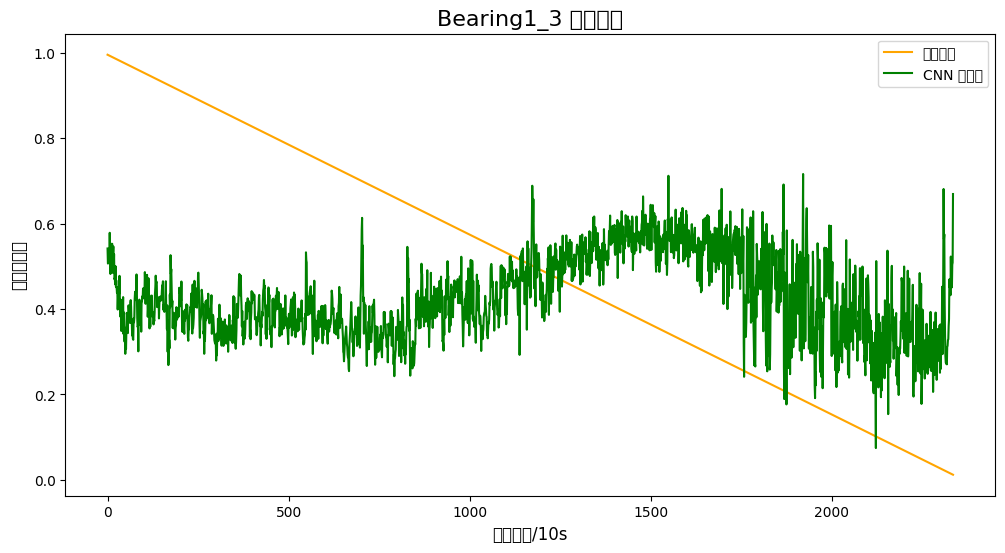

FileNotFoundError: [Errno 2] No such file or directory: '../画图对比/cnn_origin'

In [16]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test__pre_data, label='CNN 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../画图对比/cnn_origin') 
dump(test__pre_data, '../画图对比/cnn_pre')